# KTH 행동 인식 데이터셋 전처리

이 노트북은 KTH 행동 인식 데이터셋을 전처리합니다:
1. 비디오를 train/validation/test로 분할
2. 6가지 행동 라벨별로 정리
3. 비디오를 프레임 이미지로 변환
4. 전체 과정 시각화

## 0. 패키지 설치 (최초 1회만 실행)

⚠️ **중요**: 아래 셀을 실행하여 필요한 패키지를 설치하세요.

현재 사용 중인 conda 환경: **action**

In [5]:
# 방법 1: pip 사용 (권장)
!pip install opencv-python pandas matplotlib tqdm

# 방법 2: conda 사용 (위 방법이 안 되면 주석 해제)
# !conda install -y opencv pandas matplotlib tqdm

  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   -- ------------------------------------- 2.6/39.0 MB 13.7 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/39.0 MB 11.4 MB/s eta 0:00:04
   ------ --------------------------------- 6.8/39.0 MB 11.5 MB/s eta 0:00:03
   --------- ------------------------------ 9.4/39.0 MB 11.6 MB/s eta 0:00:03
   ------------ --------------------------- 12.6/39.0 MB 12.2 MB/s eta 0:00:03
   --------------- ------------------------ 15.2/39.0 MB 12.3 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/39.0 MB 12.4 MB/s eta 0:00:02
   --------------------- ------------------ 20.7/39.0 MB 12.6 MB/s eta 0:00:02
   ----------------------- ---------------- 23.1/39.0 MB 12.6 MB/s eta 0:00:02
   -------------------------- ------------- 26.2/39.0 MB 12.7 MB/s eta 0:00:02
   ----------------------------- ---------- 28.8/39.0 MB 12.7 MB

## 1. 설정 및 라이브러리 임포트

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import shutil
from tqdm import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (matplotlib)
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except:
    print("경고: 한글 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.")

print("✓ 라이브러리 임포트 완료")
print(f"OpenCV 버전: {cv2.__version__}")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

✓ 라이브러리 임포트 완료
OpenCV 버전: 4.12.0
NumPy 버전: 2.2.6
Pandas 버전: 2.3.3


## 2. 설정 및 상수 정의

In [7]:
# 기본 경로
BASE_DIR = Path(r'C:\Users\HKIT\Desktop\archive')
OUTPUT_DIR = BASE_DIR / 'data_preprocess'

# 6가지 행동 클래스
ACTION_LABELS = ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']

# 데이터 분할 (00sequences.txt 기준)
TRAIN_PERSONS = ['11', '12', '13', '14', '15', '16', '17', '18']
VALIDATION_PERSONS = ['19', '20', '21', '23', '24', '25', '01', '04']
TEST_PERSONS = ['22', '02', '03', '05', '06', '07', '08', '09', '10']

# 분할 매핑
SPLIT_MAPPING = {
    'train': TRAIN_PERSONS,
    'validation': VALIDATION_PERSONS,
    'test': TEST_PERSONS
}

print(f"기본 디렉토리: {BASE_DIR}")
print(f"출력 디렉토리: {OUTPUT_DIR}")
print(f"\n행동 클래스: {ACTION_LABELS}")
print(f"\n훈련 세트: {len(TRAIN_PERSONS)}명")
print(f"검증 세트: {len(VALIDATION_PERSONS)}명")
print(f"테스트 세트: {len(TEST_PERSONS)}명")

기본 디렉토리: C:\Users\HKIT\Desktop\archive
출력 디렉토리: C:\Users\HKIT\Desktop\archive\data_preprocess

행동 클래스: ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']

훈련 세트: 8명
검증 세트: 8명
테스트 세트: 9명


## 3. 디렉토리 구조 생성

In [8]:
def create_directory_structure():
    """data_preprocess 디렉토리 구조 생성"""
    
    # 메인 출력 디렉토리 생성
    OUTPUT_DIR.mkdir(exist_ok=True)
    print(f"✓ 메인 디렉토리 생성: {OUTPUT_DIR}")
    
    # 각 분할(train/validation/test)에 대해
    for split in ['train', 'validation', 'test']:
        split_dir = OUTPUT_DIR / split
        split_dir.mkdir(exist_ok=True)
        
        # 각 행동 라벨에 대해 디렉토리 생성
        for action in ACTION_LABELS:
            action_dir = split_dir / action
            action_dir.mkdir(exist_ok=True)
        
        print(f"✓ {split} 디렉토리 및 하위 폴더 생성 완료")
    
    print("\n디렉토리 구조:")
    print("data_preprocess/")
    print("├── train/")
    print("│   ├── boxing/")
    print("│   ├── handclapping/")
    print("│   ├── handwaving/")
    print("│   ├── jogging/")
    print("│   ├── running/")
    print("│   └── walking/")
    print("├── validation/")
    print("│   └── (동일한 구조)")
    print("└── test/")
    print("    └── (동일한 구조)")

# 디렉토리 생성 실행
create_directory_structure()

✓ 메인 디렉토리 생성: C:\Users\HKIT\Desktop\archive\data_preprocess
✓ train 디렉토리 및 하위 폴더 생성 완료
✓ validation 디렉토리 및 하위 폴더 생성 완료
✓ test 디렉토리 및 하위 폴더 생성 완료

디렉토리 구조:
data_preprocess/
├── train/
│   ├── boxing/
│   ├── handclapping/
│   ├── handwaving/
│   ├── jogging/
│   ├── running/
│   └── walking/
├── validation/
│   └── (동일한 구조)
└── test/
    └── (동일한 구조)


## 4. 비디오 파일 파싱 및 정리

In [9]:
def parse_video_filename(video_path):
    """비디오 파일명에서 정보 추출
    
    예: person01_boxing_d1_uncomp.avi
    -> person_id: '01', action: 'boxing', condition: 'd1'
    """
    filename = video_path.stem  # 확장자 제외한 파일명
    parts = filename.split('_')
    
    # person01 -> 01
    person_id = parts[0].replace('person', '')
    action = parts[1]
    condition = parts[2]
    
    return person_id, action, condition

def get_split_for_person(person_id):
    """사람 ID로 어느 분할(train/validation/test)에 속하는지 결정"""
    for split, persons in SPLIT_MAPPING.items():
        if person_id in persons:
            return split
    return None

def organize_videos():
    """비디오 파일을 적절한 디렉토리로 복사"""
    
    stats = defaultdict(lambda: defaultdict(int))
    video_info = []
    
    # 모든 행동 클래스의 비디오 찾기
    all_videos = []
    for action in ACTION_LABELS:
        action_dir = BASE_DIR / action
        if action_dir.exists():
            videos = list(action_dir.glob('*.avi'))
            all_videos.extend(videos)
    
    print(f"총 {len(all_videos)}개의 비디오 파일 발견\n")
    
    # 각 비디오 처리
    for video_path in tqdm(all_videos, desc="비디오 정리 중"):
        # 파일명 파싱
        person_id, action, condition = parse_video_filename(video_path)
        
        # 분할 결정
        split = get_split_for_person(person_id)
        
        if split is None:
            print(f"경고: person{person_id}는 어느 분할에도 속하지 않습니다.")
            continue
        
        # 대상 디렉토리
        target_dir = OUTPUT_DIR / split / action
        target_path = target_dir / video_path.name
        
        # 비디오 복사 (이미 존재하지 않는 경우)
        if not target_path.exists():
            shutil.copy2(video_path, target_path)
        
        # 통계 업데이트
        stats[split][action] += 1
        video_info.append({
            'video': video_path.name,
            'person_id': person_id,
            'action': action,
            'condition': condition,
            'split': split
        })
    
    return stats, pd.DataFrame(video_info)

# 비디오 정리 실행
stats, video_df = organize_videos()

print("\n=== 비디오 분포 통계 ===")
for split in ['train', 'validation', 'test']:
    print(f"\n{split.upper()}:")
    total = sum(stats[split].values())
    print(f"  총 비디오 수: {total}")
    for action in ACTION_LABELS:
        count = stats[split][action]
        print(f"  - {action}: {count}개")

총 499개의 비디오 파일 발견



비디오 정리 중: 100%|██████████| 499/499 [00:09<00:00, 54.70it/s] 


=== 비디오 분포 통계 ===

TRAIN:
  총 비디오 수: 159
  - boxing: 32개
  - handclapping: 31개
  - handwaving: 32개
  - jogging: 32개
  - running: 32개
  - walking: 0개

VALIDATION:
  총 비디오 수: 160
  - boxing: 32개
  - handclapping: 32개
  - handwaving: 32개
  - jogging: 32개
  - running: 32개
  - walking: 0개

TEST:
  총 비디오 수: 180
  - boxing: 36개
  - handclapping: 36개
  - handwaving: 36개
  - jogging: 36개
  - running: 36개
  - walking: 0개


## 5. 데이터 분포 시각화

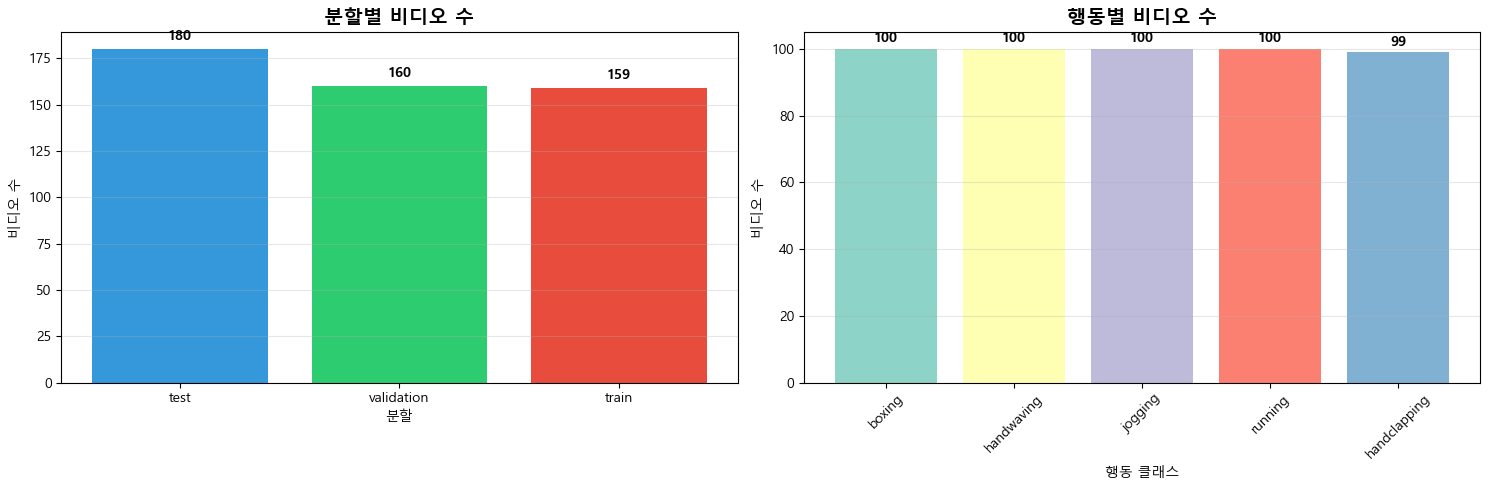

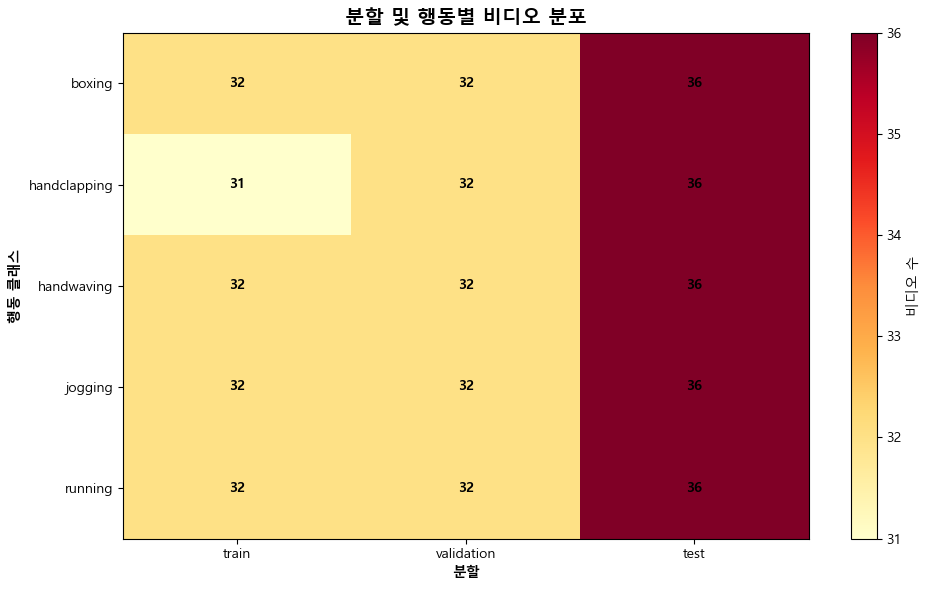

In [10]:
# 분할별 비디오 수
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 분할별 비디오 수
split_counts = video_df['split'].value_counts()
axes[0].bar(split_counts.index, split_counts.values, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('분할별 비디오 수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('분할')
axes[0].set_ylabel('비디오 수')
axes[0].grid(axis='y', alpha=0.3)

# 값 표시
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. 행동별 비디오 수
action_counts = video_df['action'].value_counts()
colors = plt.cm.Set3(range(len(action_counts)))
axes[1].bar(action_counts.index, action_counts.values, color=colors)
axes[1].set_title('행동별 비디오 수', fontsize=14, fontweight='bold')
axes[1].set_xlabel('행동 클래스')
axes[1].set_ylabel('비디오 수')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# 값 표시
for i, v in enumerate(action_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. 분할 및 행동별 히트맵
pivot_table = video_df.pivot_table(index='action', columns='split', aggfunc='size', fill_value=0)
pivot_table = pivot_table[['train', 'validation', 'test']]  # 순서 정렬

plt.figure(figsize=(10, 6))
plt.imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='비디오 수')
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.xlabel('분할', fontweight='bold')
plt.ylabel('행동 클래스', fontweight='bold')
plt.title('분할 및 행동별 비디오 분포', fontsize=14, fontweight='bold')

# 각 셀에 값 표시
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        text = plt.text(j, i, pivot_table.values[i, j],
                       ha="center", va="center", color="black", fontweight='bold')

plt.tight_layout()
plt.show()

## 6. 비디오를 프레임으로 변환

In [11]:
def extract_frames_from_video(video_path, output_dir, max_frames=None):
    """비디오에서 프레임 추출
    
    Args:
        video_path: 비디오 파일 경로
        output_dir: 프레임을 저장할 디렉토리
        max_frames: 최대 프레임 수 (None이면 모든 프레임)
    
    Returns:
        추출된 프레임 수
    """
    # 출력 디렉토리 생성
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 비디오 열기
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"경고: {video_path.name}을 열 수 없습니다.")
        return 0
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # 최대 프레임 수 체크
        if max_frames and frame_count >= max_frames:
            break
        
        # 프레임 저장
        frame_filename = output_dir / f"frame_{frame_count:04d}.jpg"
        cv2.imwrite(str(frame_filename), frame)
        
        frame_count += 1
    
    cap.release()
    return frame_count

def process_all_videos(sample_only=False, sample_per_action=2):
    """모든 비디오를 프레임으로 변환
    
    Args:
        sample_only: True면 샘플만 처리 (테스트용)
        sample_per_action: 행동당 처리할 샘플 수
    """
    
    frame_stats = []
    
    for split in ['train', 'validation', 'test']:
        split_dir = OUTPUT_DIR / split
        
        for action in ACTION_LABELS:
            action_dir = split_dir / action
            videos = list(action_dir.glob('*.avi'))
            
            # 샘플 모드인 경우 일부만 처리
            if sample_only:
                videos = videos[:sample_per_action]
            
            print(f"\n{split}/{action}: {len(videos)}개 비디오 처리 중...")
            
            for video_path in tqdm(videos, desc=f"{split}/{action}"):
                # 프레임 저장 디렉토리
                video_name = video_path.stem
                frames_dir = action_dir / video_name / 'frames'
                
                # 이미 처리된 경우 건너뛰기
                if frames_dir.exists() and len(list(frames_dir.glob('*.jpg'))) > 0:
                    frame_count = len(list(frames_dir.glob('*.jpg')))
                else:
                    # 프레임 추출
                    frame_count = extract_frames_from_video(video_path, frames_dir)
                
                frame_stats.append({
                    'split': split,
                    'action': action,
                    'video': video_name,
                    'frame_count': frame_count
                })
    
    return pd.DataFrame(frame_stats)

# 샘플 비디오로 먼저 테스트 (각 행동당 2개씩)
print("=== 샘플 비디오 처리 (테스트) ===")
frame_df_sample = process_all_videos(sample_only=True, sample_per_action=2)

print("\n샘플 처리 완료!")
print(frame_df_sample.groupby(['split', 'action'])['frame_count'].describe())

=== 샘플 비디오 처리 (테스트) ===

train/boxing: 2개 비디오 처리 중...


train/boxing: 100%|██████████| 2/2 [00:00<00:00,  2.85it/s]



train/handclapping: 2개 비디오 처리 중...


train/handclapping: 100%|██████████| 2/2 [00:00<00:00,  3.83it/s]



train/handwaving: 2개 비디오 처리 중...


...


test/running: 2개 비디오 처리 중...


test/running: 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]



test/walking: 0개 비디오 처리 중...


test/walking: 0it [00:00, ?it/s]


샘플 처리 완료!
                         count   mean         std    min     25%    50%  \
split      action                                                         
test       boxing          2.0  444.0   22.627417  428.0  436.00  444.0   
           handclapping    2.0  394.0    5.656854  390.0  392.00  394.0   
           handwaving      2.0  495.0   77.781746  440.0  467.50  495.0   
           jogging         2.0  485.5  198.697006  345.0  415.25  485.5   
           running         2.0  903.0  832.971788  314.0  608.50  903.0   
train      boxing          2.0  448.0  137.178716  351.0  399.50  448.0   
           handclapping    2.0  310.0   14.142136  300.0  305.00  310.0   
           handwaving      2.0  452.0   32.526912  429.0  440.50  452.0   
           jogging         2.0  425.0   35.355339  400.0  412.50  425.0   
           running         2.0  462.5   17.677670  450.0  456.25  462.5   
validation boxing          2.0  375.0   21.213203  360.0  367.50  375.0   
           han

## 7. 샘플 프레임 시각화

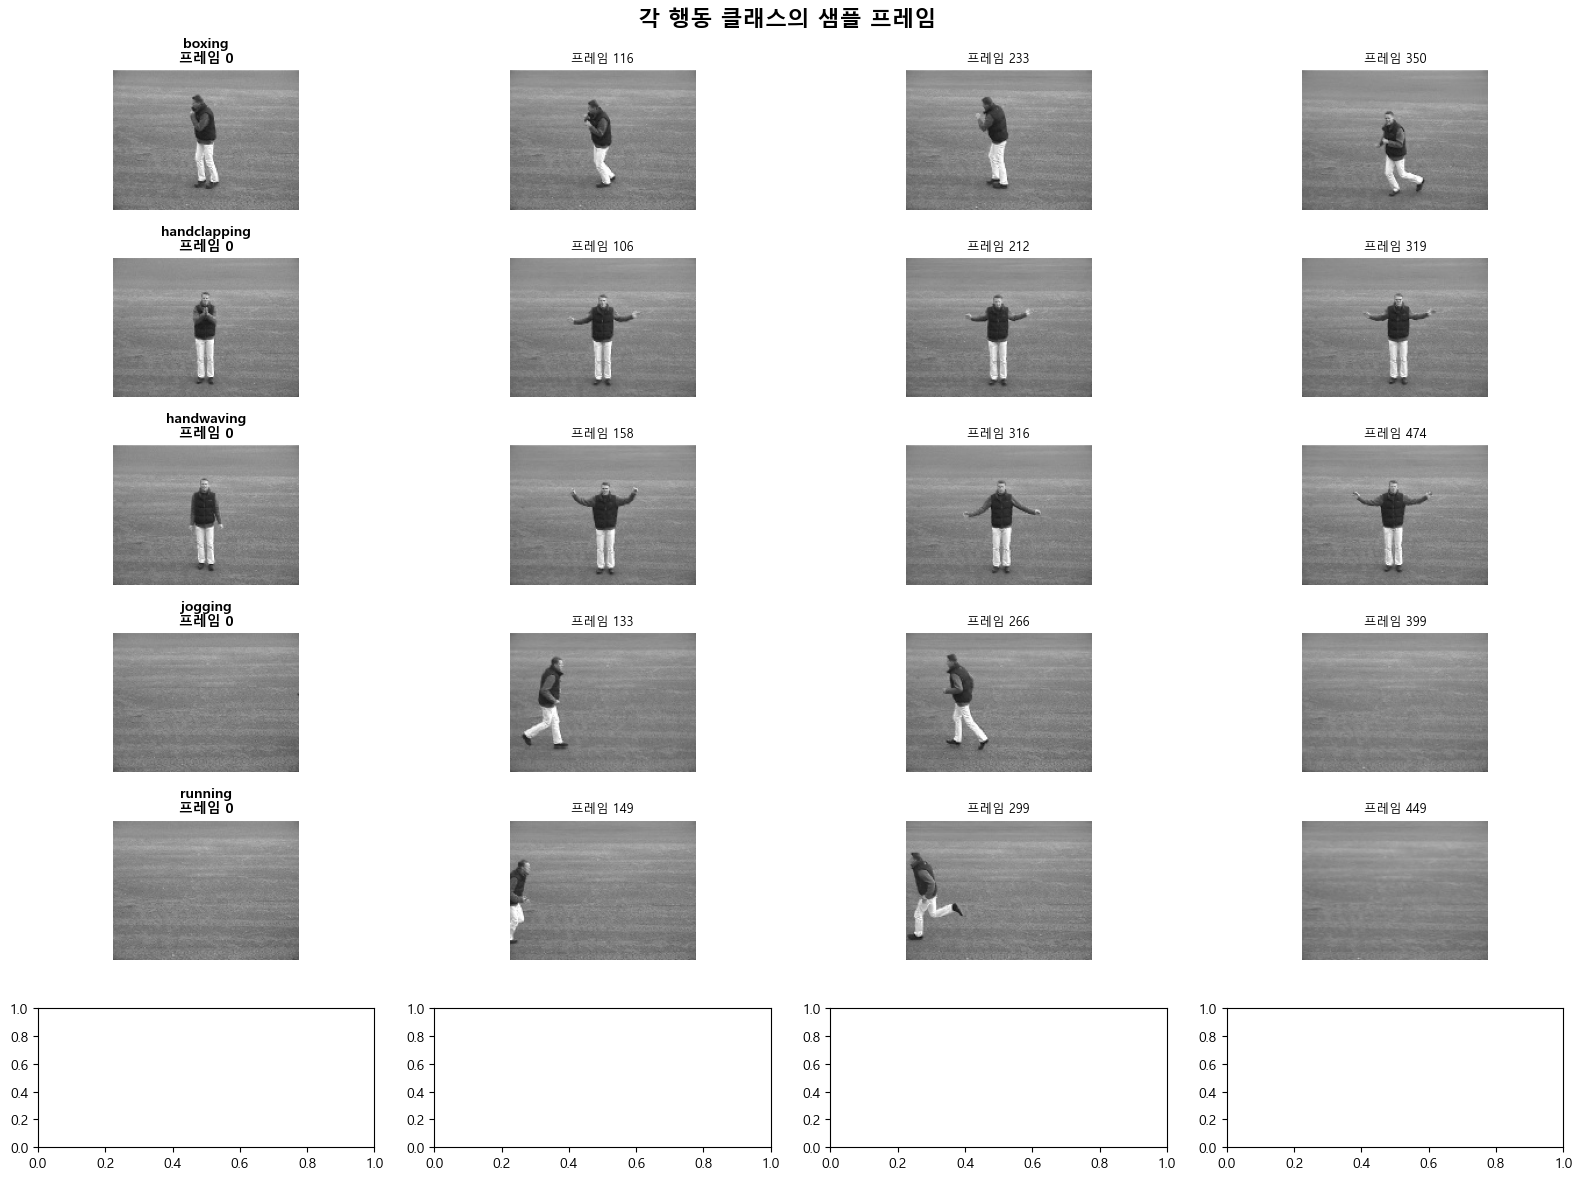

In [12]:
def visualize_sample_frames(num_actions=6, frames_per_action=4):
    """각 행동 클래스의 샘플 프레임 시각화"""
    
    fig, axes = plt.subplots(num_actions, frames_per_action, figsize=(16, 12))
    fig.suptitle('각 행동 클래스의 샘플 프레임', fontsize=16, fontweight='bold')
    
    for i, action in enumerate(ACTION_LABELS):
        # train 세트에서 첫 번째 비디오 찾기
        action_dir = OUTPUT_DIR / 'train' / action
        video_dirs = [d for d in action_dir.iterdir() if d.is_dir()]
        
        if not video_dirs:
            continue
        
        # 첫 번째 비디오의 프레임 디렉토리
        frames_dir = video_dirs[0] / 'frames'
        frame_files = sorted(frames_dir.glob('*.jpg'))
        
        if not frame_files:
            continue
        
        # 균등하게 분포된 프레임 선택
        total_frames = len(frame_files)
        indices = np.linspace(0, total_frames-1, frames_per_action, dtype=int)
        
        for j, idx in enumerate(indices):
            frame_path = frame_files[idx]
            img = cv2.imread(str(frame_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_title(f"{action}\n프레임 {idx}", 
                                    fontweight='bold', fontsize=10)
            else:
                axes[i, j].set_title(f"프레임 {idx}", fontsize=9)
    
    plt.tight_layout()
    plt.show()

# 샘플 프레임 시각화
visualize_sample_frames()

## 8. 프레임 통계 시각화

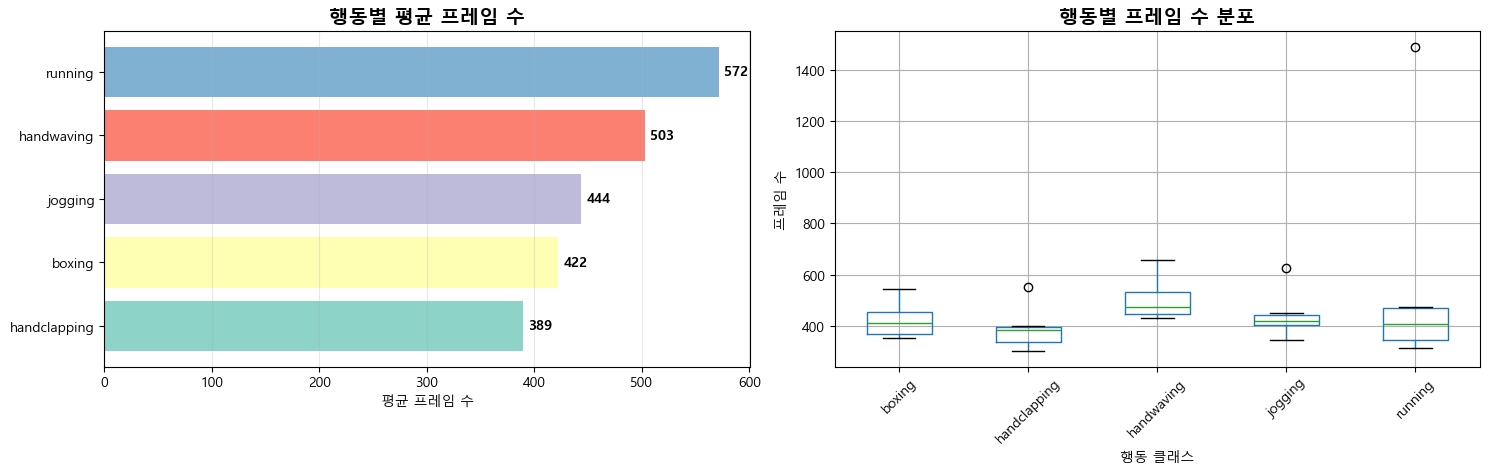


=== 프레임 통계 요약 ===
              count        mean         std    min     25%    50%     75%  \
action                                                                      
boxing          6.0  422.333333   72.824904  351.0  367.50  409.0  452.00   
handclapping    6.0  389.333333   88.096916  300.0  334.50  384.0  396.00   
handwaving      6.0  503.000000   86.106910  429.0  447.00  471.5  531.25   
jogging         6.0  443.500000   96.018227  345.0  403.75  420.0  443.75   
running         6.0  571.833333  455.252640  314.0  342.50  407.5  468.75   

                 max  
action                
boxing         545.0  
handclapping   550.0  
handwaving     656.0  
jogging        626.0  
running       1492.0  


In [13]:
# 프레임 수 분포
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 행동별 평균 프레임 수
action_frame_avg = frame_df_sample.groupby('action')['frame_count'].mean().sort_values()
axes[0].barh(action_frame_avg.index, action_frame_avg.values, color=plt.cm.Set3(range(len(action_frame_avg))))
axes[0].set_title('행동별 평균 프레임 수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('평균 프레임 수')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(action_frame_avg.values):
    axes[0].text(v + 5, i, f"{v:.0f}", va='center', fontweight='bold')

# 2. 프레임 수 분포 (박스플롯)
frame_df_sample.boxplot(column='frame_count', by='action', ax=axes[1])
axes[1].set_title('행동별 프레임 수 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('행동 클래스')
axes[1].set_ylabel('프레임 수')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')  # 기본 제목 제거

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 프레임 통계 요약 ===")
print(frame_df_sample.groupby('action')['frame_count'].describe())

## 9. 전체 데이터셋 처리 (선택사항)

⚠️ **주의**: 이 셀을 실행하면 모든 비디오를 프레임으로 변환합니다. 시간이 오래 걸릴 수 있습니다!

In [14]:
# 전체 데이터셋 처리를 원하면 아래 주석을 해제하세요
print("=== 전체 데이터셋 처리 시작 ===")
frame_df_full = process_all_videos(sample_only=False)
print("\n전체 처리 완료!")
print(frame_df_full.groupby(['split', 'action'])['frame_count'].describe())

#print("전체 데이터셋을 처리하려면 위의 주석을 해제하고 실행하세요.")

=== 전체 데이터셋 처리 시작 ===

train/boxing: 32개 비디오 처리 중...


train/boxing: 100%|██████████| 32/32 [00:16<00:00,  1.89it/s]



train/handclapping: 31개 비디오 처리 중...


train/handclapping: 100%|██████████| 31/31 [00:10<00:00,  2.89it/s]



train/handwaving: 32개 비디오 처리 중...


...


test/running: 36개 비디오 처리 중...


test/running: 100%|██████████| 36/36 [00:11<00:00,  3.03it/s]



test/walking: 0개 비디오 처리 중...


test/walking: 0it [00:00, ?it/s]


전체 처리 완료!
                         count        mean         std    min     25%    50%  \
split      action                                                              
test       boxing         36.0  439.166667   48.828270  302.0  414.75  433.0   
           handclapping   36.0  416.111111   53.888126  284.0  384.25  419.0   
           handwaving     36.0  512.000000  106.708414  360.0  444.50  482.0   
           jogging        36.0  425.166667   94.785623  304.0  350.00  400.0   
           running        36.0  408.027778  233.242300  256.0  309.00  339.5   
train      boxing         32.0  497.625000  117.134263  250.0  419.75  490.0   
           handclapping   31.0  436.258065   77.597667  285.0  387.50  450.0   
           handwaving     32.0  547.718750  110.986844  330.0  487.75  548.5   
           jogging        32.0  471.687500   78.798001  320.0  413.75  465.0   
           running        32.0  400.187500   84.162453  270.0  340.50  385.0   
validation boxing         32.

## 10. 최종 요약

In [15]:
print("="*60)
print("전처리 완료 요약")
print("="*60)

print(f"\n출력 디렉토리: {OUTPUT_DIR}")
print(f"\n디렉토리 구조:")
print(f"  data_preprocess/")
print(f"    ├── train/ ({len(TRAIN_PERSONS)}명의 피험자)")
print(f"    ├── validation/ ({len(VALIDATION_PERSONS)}명의 피험자)")
print(f"    └── test/ ({len(TEST_PERSONS)}명의 피험자)")

print(f"\n행동 클래스: {len(ACTION_LABELS)}개")
for action in ACTION_LABELS:
    print(f"  - {action}")

print(f"\n비디오 분포:")
for split in ['train', 'validation', 'test']:
    count = len(video_df[video_df['split'] == split])
    print(f"  {split}: {count}개")

print(f"\n샘플 프레임 추출 완료: {len(frame_df_sample)}개 비디오")
print(f"평균 프레임 수: {frame_df_sample['frame_count'].mean():.1f}")

print("\n" + "="*60)
print("✓ 전처리 파이프라인 실행 완료!")
print("="*60)

전처리 완료 요약

출력 디렉토리: C:\Users\HKIT\Desktop\archive\data_preprocess

디렉토리 구조:
  data_preprocess/
    ├── train/ (8명의 피험자)
    ├── validation/ (8명의 피험자)
    └── test/ (9명의 피험자)

행동 클래스: 6개
  - boxing
  - handclapping
  - handwaving
  - jogging
  - running
  - walking

비디오 분포:
  train: 159개
  validation: 160개
  test: 180개

샘플 프레임 추출 완료: 30개 비디오
평균 프레임 수: 466.0

✓ 전처리 파이프라인 실행 완료!
